In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape, X_test.shape)

(8000, 42) (2000, 42)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7125
Precision: 0.20508744038155802
Recall: 0.6323529411764706
F1: 0.3097238895558223
ROC-AUC: 0.7571482379143194

Confusion Matrix:
[[1296  500]
 [  75  129]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      1796
           1       0.21      0.63      0.31       204

    accuracy                           0.71      2000
   macro avg       0.58      0.68      0.56      2000
weighted avg       0.87      0.71      0.77      2000



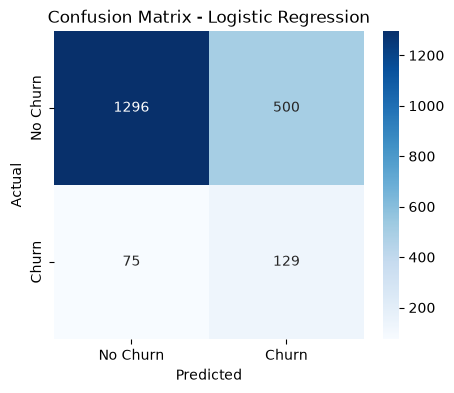

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

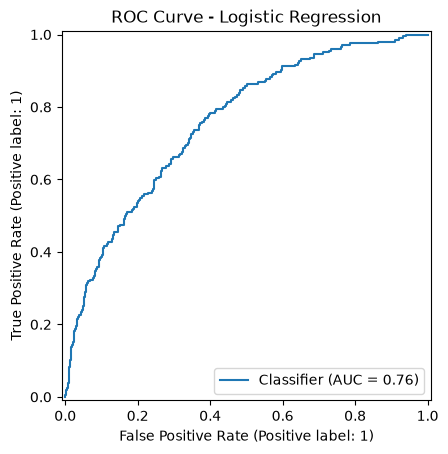

In [10]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)  # tree-based models don't need scaling

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.883
Precision: 0.2972972972972973
Recall: 0.10784313725490197
F1: 0.15827338129496402
ROC-AUC: 0.7311154417223461

Confusion Matrix:
[[1744   52]
 [ 182   22]]


In [13]:
import numpy as np
print("RF predicted probabilities for actual churners (y_test==1):")
print(pd.Series(y_proba_rf[y_test==1]).describe())

print("\nRF predicted probabilities for actual non-churners (y_test==0):")
print(pd.Series(y_proba_rf[y_test==0]).describe())

RF predicted probabilities for actual churners (y_test==1):
count    204.000000
mean       0.300564
std        0.149409
min        0.005000
25%        0.198750
50%        0.280000
75%        0.405000
max        0.715000
dtype: float64

RF predicted probabilities for actual non-churners (y_test==0):
count    1796.000000
mean        0.179649
std         0.142217
min         0.000000
25%         0.063750
50%         0.145000
75%         0.270000
max         0.755000
dtype: float64


In [16]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

scale_pos_weight: 8.828009828009828
Accuracy: 0.7695
Precision: 0.21252796420581654
Recall: 0.46568627450980393
F1: 0.29185867895545314
ROC-AUC: 0.7275972749901742

Confusion Matrix:
[[1444  352]
 [ 109   95]]


In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"
)

random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=30,
    scoring="roc_auc", cv=5, random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.7645678761714862


In [18]:
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Accuracy: 0.7115
Precision: 0.2025518341307815
Recall: 0.6225490196078431
F1: 0.3056558363417569
ROC-AUC: 0.7481221887418666

Confusion Matrix:
[[1296  500]
 [  77  127]]


In [19]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df.head(15))

                      feature  coefficient
31                operator_Vi     0.487164
7                  has_bundle    -0.353241
39       tenure_growing_4_12m    -0.324867
41      tenure_loyal_36m_plus    -0.318683
38           dormant_45d_flag     0.310568
37       high_complaints_flag     0.307677
6              network_rating    -0.292468
40  tenure_established_13_36m    -0.287152
9               is_active_vlr    -0.271482
29              operator_BSNL     0.266077
2               tenure_months    -0.156737
32          plan_type_Prepaid     0.152874
4    days_since_last_recharge     0.130438
0                         age     0.088249
17      circle_Madhya Pradesh     0.067642


C:\Users\SUN\indian-telecom-churn-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 8000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8000 when initializing the masker.


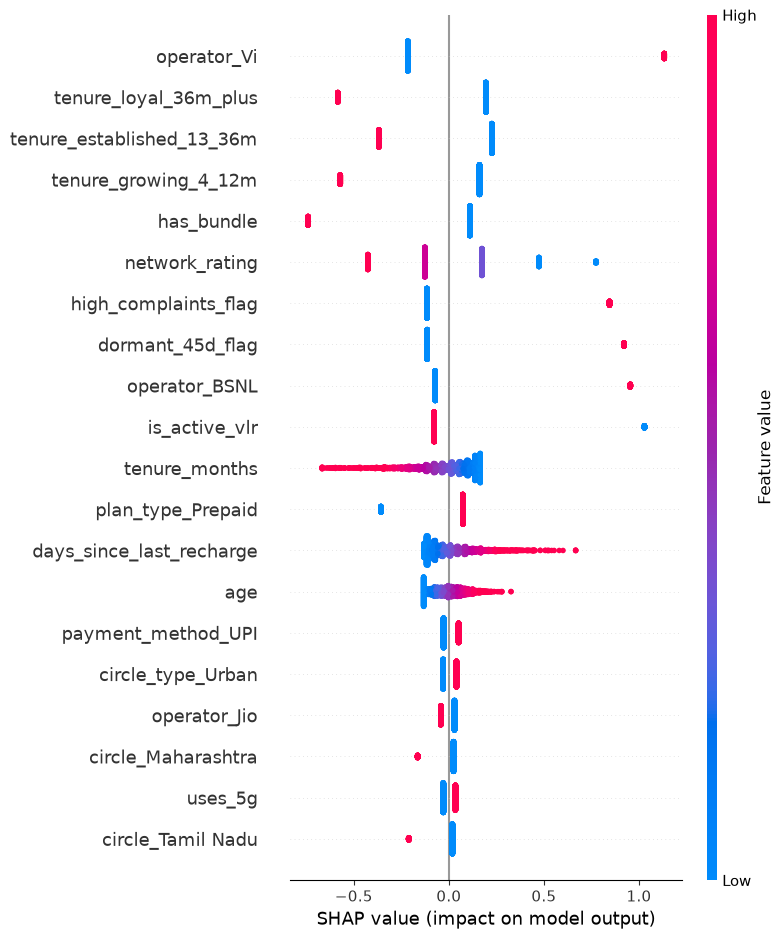

In [22]:
import shap

explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)

In [23]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(log_reg, "../models/logistic_regression_churn.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

# Save test predictions for potential later use (e.g. dashboard)
results_df = X_test.copy()
results_df["actual_churn"] = y_test.values
results_df["predicted_churn"] = y_pred
results_df["churn_probability"] = y_proba
results_df.to_csv("../data/processed/test_predictions.csv", index=False)

print("Saved model, scaler, and test predictions")

Saved model, scaler, and test predictions


## Phase 3 Summary: Churn Prediction Modeling

1. Trained and compared 4 model configurations: Logistic Regression (scaled features), 
   Random Forest, XGBoost (default), and XGBoost (tuned via RandomizedSearchCV, 30 
   iterations, 5-fold CV on ROC-AUC).

2. **Logistic Regression was selected as the primary model**: ROC-AUC 0.757, F1 0.308, 
   Recall 0.627, Precision 0.204 - the best ROC-AUC of all four, despite being the 
   simplest model.

3. Random Forest had the highest accuracy (0.883) but the lowest recall (0.108) - a 
   clear example of accuracy being misleading on imbalanced data; its probabilities 
   were heavily compressed toward 0 even for actual churners (mean 0.30 vs 0.18).

4. Tuned XGBoost (max_depth=3, learning_rate=0.01, min_child_weight=5) converged to 
   nearly the same operating point as Logistic Regression (ROC-AUC 0.748), suggesting 
   the dataset's signal is largely additive/linear - consistent with our EDA-driven 
   feature engineering (dormant_45d_flag, high_complaints_flag) already capturing the 
   main non-linear effects.

5. Model interpretation (coefficients + SHAP) confirmed a coherent business story: 
   operator (Vi/BSNL risk), engagement signals (dormancy, complaints, VLR status), 
   bundling, and customer lifecycle stage are the top churn drivers - directly 
   traceable to Phase 1 EDA findings.

**Next**: Phase 4 - Retention A/B test analysis (statistical significance, power 
analysis, segment-level effects) using `retention_ab_test.csv`.